# Data models with XGBoost

In [1]:
import sys, os, joblib
import pyreadstat
import pickle
import ast, sqlalchemy, psycopg2
import umap
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

2025-06-10 13:04:56.712219: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-10 13:04:56.726700: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749553496.744220   11620 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749553496.749604   11620 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-10 13:04:56.767635: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
# Acuerdate de guardar los datos procesados
file = './trombo_dat2.pkl'
with  open(file,'rb') as fd:
    patD  = pickle.load(fd)
    ldata = pickle.load(fd)
    data  = pickle.load(fd)
#


In [3]:
data.shape

(22874, 16)

In [4]:
patD.shape

(22874, 174)

In [5]:
patD.columns

Index(['id_pacie', 'sexo', 'edad', 'raza', 'peso', 'talla', 'tension_',
       'fecha_di', 'f_alta_h', 'ant_inf',
       ...
       'seco', 'secopri', 'f_secop', 'secopres', 'edadC', 'pesoC', 'tensionC',
       'fr_can_eC', 'trb_splcnc', 'othr_TUS'],
      dtype='object', length=174)

In [6]:
conditionsc = [
    (patD['ana_hemo'] < 12), # Condition for 'w cancer & Metástasis'
    (patD['ana_hemo']>= 12),
    (patD['ana_hemo'].isna())
]
choicesc = ['Bajo', 'Normal','Normal']
patD['ana_hemoC'] = np.select(conditionsc, choicesc)

patD.loc[:,'ana_hemoC'].value_counts(dropna=False)

ana_hemoC
Normal    18564
Bajo       4310
Name: count, dtype: int64

In [7]:
conditionsc = [
    (patD['ana_plaq'] < 140), # Condition for 'w cancer & Metástasis'
    ((patD['ana_plaq'] >= 140) & (patD['ana_plaq'] < 400)),
    ((patD['ana_plaq']>= 400) & (patD['ana_plaq'] < 140000)),
    ((patD['ana_plaq']> 140000) & (patD['ana_plaq']< 400000)),
    (patD['ana_plaq']> 400000),
    (patD['ana_plaq'].isna())
]
choicesc = ['Bajo', 'Normal','Alto','Normal','Alto','Normal']
patD['ana_plaqC'] = np.select(conditionsc, choicesc)

patD.loc[:,'ana_plaqC'].value_counts(dropna=False)

ana_plaqC
Normal    19767
Bajo       1930
Alto       1177
Name: count, dtype: int64

In [8]:
conditionsc = [
    (patD['ana_neu'] < 2.5), # Condition for 'w cancer & Metástasis'
    (patD['ana_neu'] > 12),
    ((patD['ana_neu'] >= 2.5) & (patD['ana_neu'] <= 12)),
    (patD['ana_neu'].isnull())
]
choicesc = ['Bajo', 'Alto','Normal','Normal']
patD['ana_neuC'] = np.select(conditionsc, choicesc)
patD.loc[:,'ana_neuC'].value_counts(dropna=False)

ana_neuC
Normal    22490
Alto        237
Bajo        147
Name: count, dtype: int64

In [9]:
conditionsc = [
    (patD['ana_leuc'] < 4.5), # Condition for 'w cancer & Metástasis'
    (patD['ana_leuc'] > 11),
    ((patD['ana_leuc'] >= 4.5) & (patD['ana_leuc'] <= 11)),
    (patD['ana_leuc'].isnull())
]
choicesc = ['Bajo', 'Alto','Normal','Normal']
patD['ana_leucC'] = np.select(conditionsc, choicesc)
patD.loc[:,'ana_leucC'].value_counts(dropna=False)

ana_leucC
Normal    15999
Alto       6093
Bajo        782
Name: count, dtype: int64

In [10]:
conditionsc = [
    (patD['ana_dime'] == 'Positivo'), # Condition for 'w cancer & Metástasis'
    (patD['ana_dime'] == 'Negativo'),
    (patD['ana_dime'] == 'No practicado'),
    (patD['ana_dime'].isna())
]
choicesc = ['Positivo', 'Negativo','No practicado','No practicado']
patD['ana_dimeC'] = np.select(conditionsc, choicesc)
patD.loc[:,'ana_dimeC'].value_counts(dropna=False)

ana_dimeC
Positivo         15543
No practicado     6667
Negativo           664
Name: count, dtype: int64

In [11]:
patD['ana_dime'].value_counts(dropna=False)

ana_dime
Positivo         15543
No practicado     5064
NaN               1603
Negativo           664
Name: count, dtype: int64

In [12]:
patD['ana_crea']

0          Normal
6          Normal
7          Normal
10        Elevada
34         Normal
           ...   
119381     Normal
119393     Normal
119394        NaN
119399     Normal
119412    Elevada
Name: ana_crea, Length: 22874, dtype: category
Categories (2, object): ['Elevada', 'Normal']

In [13]:
conditionsc = [
    (patD['ana_crea'] == 'Elevada'), # Condition for 'w cancer & Metástasis'
    (patD['ana_crea'] == 'Normal'),
    (patD['ana_crea'].isna())
]
choicesc = ['Elevada', 'Normal','Normal']
patD['ana_creaC'] = np.select(conditionsc, choicesc)
patD.loc[:,'ana_creaC'].value_counts(dropna=False)

ana_creaC
Normal     20527
Elevada     2347
Name: count, dtype: int64

In [14]:
cls = [ cl for cl in patD.columns if cl in ['ana_dura', 'sexo', 'edadC', 'raza', 'pesoC', 
                                            'tensionC', 'ant_inf', 'ant_isq', 'ant_clau', 
                                            'fum_act', 'diabetes', 'hip_art', 'insf_car', 
                                            'fibr_aur', 'trat_est', 'e_con_pp', 'e_con_cu', 
                                            'e_con_ec', 'e_con_lu', 'e_con_af', 'e_con_be', 
                                            'e_con_at', 'e_con_va', 'e_con_ar', 'e_con_ea', 
                                            'e_con_pr', 'e_con_ro', 'e_con_av', 'e_con_sm', 
                                            'sin_tvp_', 'var171', 'ep_tac_r', 'eptacven', 
                                            'ep_t_reg', 'ep_ecoca', 'ep_eco_v', 
                                            'var52', 'epecoddv', 'tvp_eco_', 'tv_l_esu', 
                                            'tv_l_ein', 'tv_l_vpo', 
                                            'tv_l_vme', 'tv_l_ves', 'tv_l_svc', 'tv_l_vre', 
                                            'tv_l_vrn', 'tv_l_vca', 'tv_l_yug', 'tv_l_ova', 
                                            'tv_l_sup', 'tv_l_pul', 'tv_l_ove', 'fr_cance', 
                                            'fr_cirug', 'fr_inmov', 'fr_tvp_a', 'fr_antfa', 
                                            'fr_tvs_a', 'fr_viaje', 'fr_estro', 'fr_embar', 
                                            'fr_varic', 'fr_antec', 'ana_hemoC', 'ana_leucC', 
                                            'ana_neuC', 'ana_plaqC', 'ana_dimeC',
                                            'ana_creaC', 'ana_trop',   
                                            'evn_defu', 'evn_reci', 'evn_rec2', 'evn_rec3', 
                                            'evn_rec4', 'evn_hemo', 'evn_hem2', 'evn_hem3', 
                                            'evn_hem4', 'eisq_art', 'eisq_inf', 'eisq_ang', 
                                            'eisq_cer', 'eisq_ei', 'eisq_ol','fr_can_eC']]
print(cls)

['sexo', 'raza', 'ant_inf', 'ant_isq', 'ant_clau', 'fum_act', 'diabetes', 'hip_art', 'insf_car', 'fibr_aur', 'trat_est', 'e_con_pp', 'e_con_cu', 'e_con_ec', 'e_con_lu', 'e_con_af', 'e_con_be', 'e_con_at', 'e_con_va', 'e_con_ar', 'e_con_ea', 'e_con_pr', 'e_con_ro', 'e_con_av', 'e_con_sm', 'sin_tvp_', 'var171', 'ep_tac_r', 'eptacven', 'ep_t_reg', 'ep_ecoca', 'ep_eco_v', 'var52', 'epecoddv', 'tvp_eco_', 'tv_l_esu', 'tv_l_ein', 'tv_l_vpo', 'tv_l_vme', 'tv_l_ves', 'tv_l_svc', 'tv_l_vre', 'tv_l_vrn', 'tv_l_vca', 'tv_l_yug', 'tv_l_ova', 'tv_l_sup', 'tv_l_pul', 'tv_l_ove', 'fr_cance', 'fr_cirug', 'fr_inmov', 'fr_tvp_a', 'fr_antfa', 'fr_tvs_a', 'fr_viaje', 'fr_estro', 'fr_embar', 'fr_varic', 'fr_antec', 'ana_trop', 'ana_dura', 'evn_defu', 'evn_reci', 'evn_rec2', 'evn_rec3', 'evn_rec4', 'evn_hemo', 'evn_hem2', 'evn_hem3', 'evn_hem4', 'eisq_art', 'eisq_inf', 'eisq_ang', 'eisq_cer', 'eisq_ei', 'eisq_ol', 'edadC', 'pesoC', 'tensionC', 'fr_can_eC', 'ana_hemoC', 'ana_plaqC', 'ana_neuC', 'ana_leucC', 

In [15]:
patD[cls]

,sexo,raza,ant_inf,ant_isq,ant_clau,fum_act,diabetes,hip_art,insf_car,fibr_aur,...,edadC,pesoC,tensionC,fr_can_eC,ana_hemoC,ana_plaqC,ana_neuC,ana_leucC,ana_dimeC,ana_creaC
0,Mujer,Caucásica,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,...,Senior,Normal,Normal,No,Normal,Normal,Normal,Normal,Positivo,Normal
6,Hombre,Caucásica,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,...,Senior,Normal,Normal,Sin metástasis,Bajo,Bajo,Normal,Alto,Positivo,Normal
7,Mujer,Caucásica,NaN,NaN,NaN,NaN,NaN,NaN,Sí,NaN,...,Senior,Normal,Normal,No,Normal,Normal,Normal,Alto,No practicado,Normal
10,Hombre,Caucásica,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,...,Senior,Normal,Normal,No,Bajo,Normal,Normal,Normal,Positivo,Elevada
34,Hombre,Caucásica,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,...,Medio,Normal,Normal,No,Normal,Bajo,Normal,Normal,Negativo,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119381,Hombre,Caucásica,No,No,No,No,No,Sí,No,No,...,Medio,Normal,Normal,No,Normal,Normal,Normal,Alto,Positivo,Normal
119393,Mujer,Caucásica,No,No,No,No,No,No,No,No,...,Joven,Normal,Normal,No,Normal,Alto,Normal,Normal,Positivo,Normal
119394,Mujer,Romaní,No,No,No,No,No,No,No,No,...,Joven,Bajo,Normal,No,Bajo,Bajo,Normal,Bajo,Positivo,Normal
119399,Hombre,Caucásica,No,No,No,No,NaN,NaN,NaN,NaN,...,Joven,Alto,Baja,No,Normal,Bajo,Normal,Normal,No practicado,Normal


In [16]:
for col in patD[cls].columns:
    patD[col].value_counts(dropna=False)
    if patD[col].isnull().any():  # Only act if there are NaNs
        if isinstance(patD[col].dtype, pd.CategoricalDtype):
            if 'No' not in patD[col].cat.categories:
                patD[col] = patD[col].cat.add_categories('No')
        patD[col] = patD[col].fillna('No')

In [17]:
patD[cls]

,sexo,raza,ant_inf,ant_isq,ant_clau,fum_act,diabetes,hip_art,insf_car,fibr_aur,...,edadC,pesoC,tensionC,fr_can_eC,ana_hemoC,ana_plaqC,ana_neuC,ana_leucC,ana_dimeC,ana_creaC
0,Mujer,Caucásica,No,No,No,No,No,No,No,No,...,Senior,Normal,Normal,No,Normal,Normal,Normal,Normal,Positivo,Normal
6,Hombre,Caucásica,No,No,No,No,No,No,No,No,...,Senior,Normal,Normal,Sin metástasis,Bajo,Bajo,Normal,Alto,Positivo,Normal
7,Mujer,Caucásica,No,No,No,No,No,No,Sí,No,...,Senior,Normal,Normal,No,Normal,Normal,Normal,Alto,No practicado,Normal
10,Hombre,Caucásica,No,No,No,No,No,No,No,No,...,Senior,Normal,Normal,No,Bajo,Normal,Normal,Normal,Positivo,Elevada
34,Hombre,Caucásica,No,No,No,No,No,No,No,No,...,Medio,Normal,Normal,No,Normal,Bajo,Normal,Normal,Negativo,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119381,Hombre,Caucásica,No,No,No,No,No,Sí,No,No,...,Medio,Normal,Normal,No,Normal,Normal,Normal,Alto,Positivo,Normal
119393,Mujer,Caucásica,No,No,No,No,No,No,No,No,...,Joven,Normal,Normal,No,Normal,Alto,Normal,Normal,Positivo,Normal
119394,Mujer,Romaní,No,No,No,No,No,No,No,No,...,Joven,Bajo,Normal,No,Bajo,Bajo,Normal,Bajo,Positivo,Normal
119399,Hombre,Caucásica,No,No,No,No,No,No,No,No,...,Joven,Alto,Baja,No,Normal,Bajo,Normal,Normal,No practicado,Normal


In [18]:
# Guardando datos en BBDD
# Parámetros de conexión
user = 'postgres'
password = 'Aproin-1'
host = '138.100.82.184'
port = '5432'
database = 'trombofilia'
table_name = 'pacientes_ok'

# Crea el engine de SQLAlchemy
engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}')

# Escribe el DataFrame en PostgreSQL
# Si la tabla ya existe, puedes usar 'replace' o 'append' según el caso
patD[cls].to_sql(table_name, engine, if_exists='replace', index=False)



374

In [19]:
summary = {}
for col in patD[cls].columns:
    summary[col] = patD[cls][col].value_counts(dropna=False)
    print(summary[col])
    print("--------------------------------")

# Si quieres ver el resumen de una columna específica:
# print(summary['nombre_de_columna'])
# summary_df = pd.concat(summary, axis=1)
# summary_df.columns.name = 'Columnas'
# summary_df.index.name = 'Valores'
# summary_df

sexo
Hombre    12093
Mujer     10781
Name: count, dtype: int64
--------------------------------
raza
Caucásica         22250
América Latina      311
Arábica             123
Romaní               68
Negra                61
Asiática             45
Otras                16
Name: count, dtype: int64
--------------------------------
ant_inf
No    22184
Sí      690
Name: count, dtype: int64
--------------------------------
ant_isq
No    22216
Sí      658
Name: count, dtype: int64
--------------------------------
ant_clau
No    22402
Sí      472
Name: count, dtype: int64
--------------------------------
fum_act
No    19381
Sí     3493
Name: count, dtype: int64
--------------------------------
diabetes
No    20924
Sí     1950
Name: count, dtype: int64
--------------------------------
hip_art
No    16642
Sí     6232
Name: count, dtype: int64
--------------------------------
insf_car
No    21974
Sí      900
Name: count, dtype: int64
--------------------------------
fibr_aur
No    22591
Sí      283

## UMAP

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


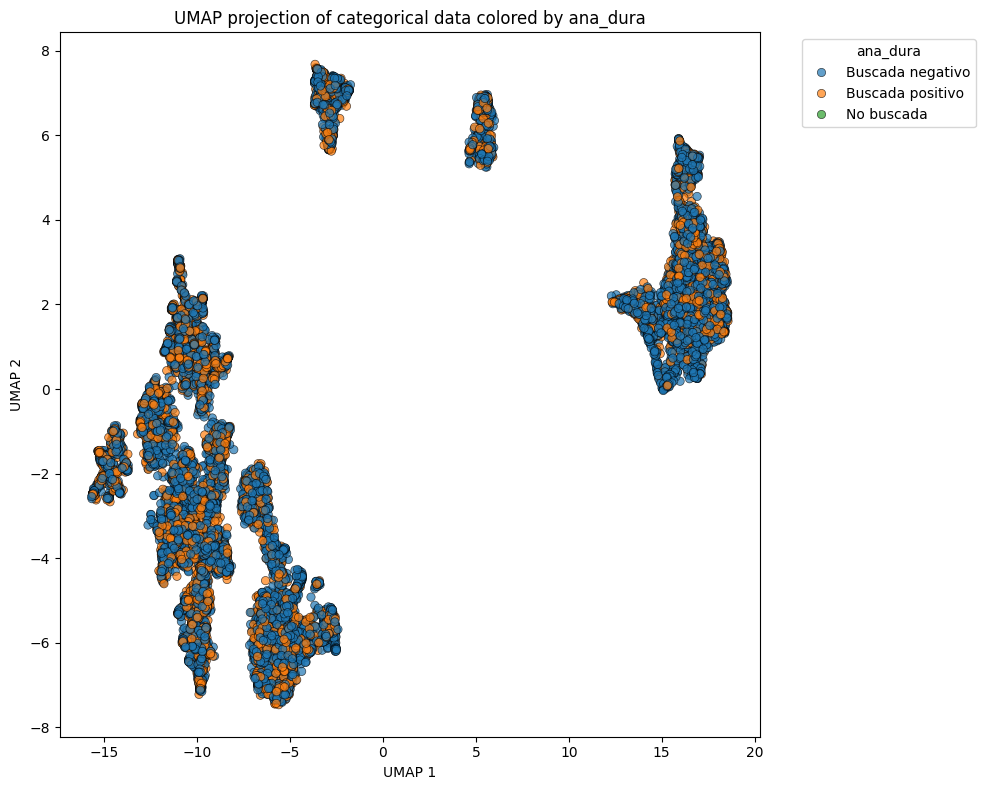

In [20]:
# Separa la variable de color
X = patD[cls].drop(columns=['ana_dura'])
y = patD[cls]['ana_dura']

# One-Hot Encoding para todas las variables categóricas
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(X)

reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X_encoded)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=y,
    palette='tab10',  # Cambia el palette si hay muchas clases
    alpha=0.7,
    edgecolor='k'
)
plt.title('UMAP projection of categorical data colored by ana_dura')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(title='ana_dura', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


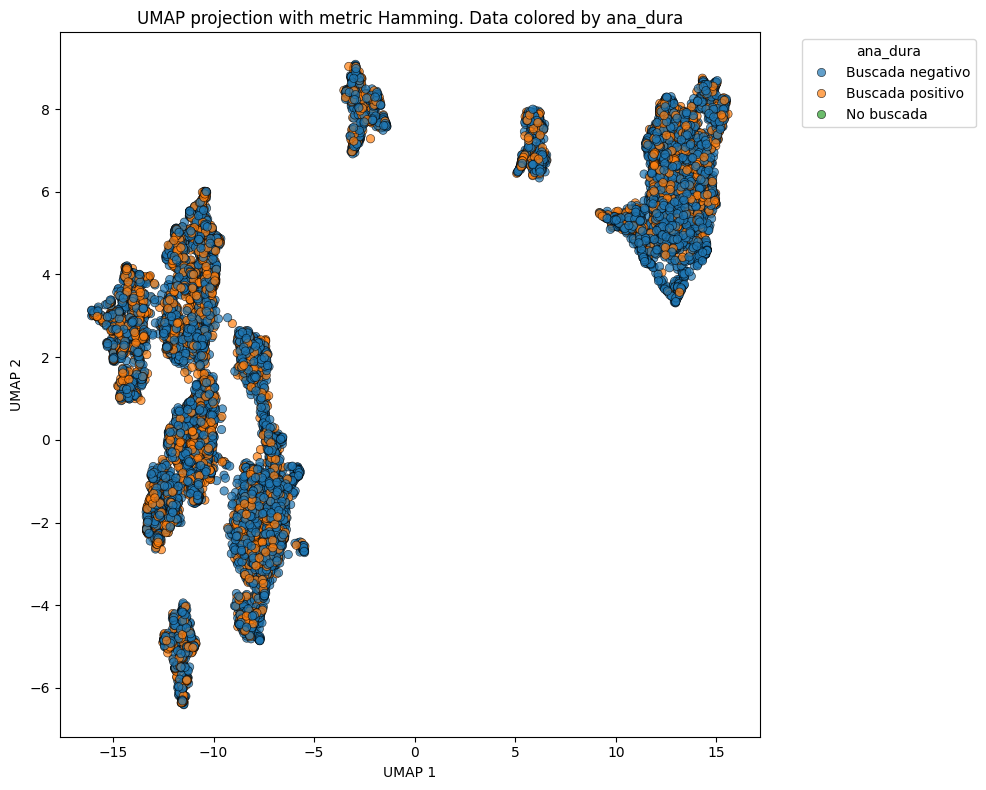

In [21]:
reducer2 = umap.UMAP(metric='hamming',random_state=42)
embedding2 = reducer2.fit_transform(X_encoded)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=embedding2[:, 0],
    y=embedding2[:, 1],
    hue=y,
    palette='tab10',  # Cambia el palette si hay muchas clases
    alpha=0.7,
    edgecolor='k'
)
plt.title('UMAP projection with metric Hamming. Data colored by ana_dura')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(title='ana_dura', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Clasificador multietiqueta

In [ ]:
mlb = MultiLabelBinarizer()
X = mlb.fit_transform(patD[cls])

In [ ]:
mlb.classes_

In [ ]:
X.shape

In [ ]:
X

In [ ]:
y = patD['ana_dura'].values
y

## Only relevant columns from experts

In [ ]:
ncls= ['sexo','edadC','sin_tvp_','trb_splcnc',
             'tv_l_esu','tv_l_svc','othr_TUS','fr_cance',
             'fr_cirug','fr_inmov','fr_tvp_a','fr_estro', # 'ana_port', => Always to No
             'evn_reci','evn_hemo']

In [ ]:
XpatD = patD[ncls]

In [ ]:
YpatD = patD['ana_dura']

In [ ]:
XpatD

## Modeling

In [ ]:
for col in patD.columns:
    if not isinstance(patD[col].dtype, pd.CategoricalDtype):
        patD[col] = patD[col].astype('category')

In [ ]:
list(zip(patD[cls].columns,list(patD[cls].dtypes)))

In [ ]:
#
# 2. Definir variable objetivo y características
cls_patD = patD[cls].copy()
y_raw = cls_patD['ana_dura'].copy()
X_raw = cls_patD.drop(columns=['ana_dura']).copy()

# 3. Convertimos y_raw a multilabel
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform([[val] for val in y_raw])
label_names = mlb.classes_

# 4. ColumnTransformer con OneHotEncoder para todas las columnas (tratadas como categóricas)
categorical_features = X_raw.columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# 5. Pipeline completo
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MultiOutputClassifier(HistGradientBoostingClassifier(random_state=42)))
])

In [ ]:
Y

In [ ]:
label_names

In [ ]:
X_raw

In [ ]:
# 6. Separar train/test
X_train, X_test, y_train, y_test = train_test_split(X_raw, Y, test_size=0.2, random_state=42)

# 7. GridSearchCV con validación cruzada (cv=5)
param_grid = {
    'classifier__estimator__learning_rate': [0.01,0.05,0.1],
    'classifier__estimator__max_depth': [5,9,13],
    'classifier__estimator__max_iter': [50,100,200]
}

In [ ]:

grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1_micro', verbose=2, n_jobs=1)
grid.fit(X_train, y_train)

# 8. Evaluación
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)


In [ ]:

print("✅ Mejores parámetros encontrados:", grid.best_params_)
print("\n📊 Clasificación por etiqueta de 'ana_dura':")
print(classification_report(y_test, y_pred, target_names=label_names))

In [ ]:
# 9. Guardar el mejor pipeline (preprocesador + modelo)
iter = grid.best_params_['classifier__estimator__max_iter']
lr   = grid.best_params_['classifier__estimator__learning_rate']
depth= grid.best_params_['classifier__estimator__max_depth']
joblib.dump(best_model, f"modelo_xgb_pipeline-{iter}-{lr}-{depth}.pkl")

#    Guardar el binarizador de la variable objetivo
joblib.dump(mlb, f"binarizador_ana_dura-{iter}-{lr}-{depth}.pkl")


In [ ]:
all_labels_proba=best_model.predict_proba(X_test)
all_labels_proba

In [ ]:
# Calcular AUC para cada etiqueta
num_labels = y_test.shape[1] # Número total de etiquetas

auc_scores_per_label = []

for i in range(num_labels):
    y_true_label_i = y_test[:, i]
    y_proba_label_i = all_labels_proba[i][:, 1] # Probabilidad de clase 1 para la etiqueta i

    # Solo calcular si la etiqueta tiene al menos una instancia de cada clase (0 y 1) en y_test
    # De lo contrario, roc_auc_score dará un error
    if len(np.unique(y_true_label_i)) == 2:
         auc_i = roc_auc_score(y_true_label_i, y_proba_label_i)
         auc_scores_per_label.append(auc_i)
         print(f"AUC ROC para la etiqueta {i}: {auc_i:.4f}")
    else:
         print(f"Etiqueta {i} tiene solo una clase en y_test, no se puede calcular AUC ROC.")
         # Puedes añadir un valor NaN o similar si quieres mantener el mismo número de entradas que etiquetas


In [ ]:
y_test.shape

In [ ]:
grid.predict(X_test)

In [ ]:
from sklearn.metrics import RocCurveDisplay

class_of_interest = "Buscada negativo"
class_id = np.flatnonzero(mlb.classes_ == class_of_interest)[0]
print(f"Class_ID:{class_id}")
display = RocCurveDisplay.from_predictions(
    y_test[:, class_id],
    grid.predict(X_test)[:,class_id],
    name=f"{class_of_interest} vs the rest",
    color="darkorange",
    plot_chance_level=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="One-vs-Rest ROC curves:\nVirginica vs (Setosa & Versicolor)",
)

In [ ]:
from sklearn.metrics import RocCurveDisplay

class_of_interest = "Buscada positivo"
class_id = np.flatnonzero(mlb.classes_ == class_of_interest)[0]
print(f"Class_ID:{class_id}")
display = RocCurveDisplay.from_predictions(
    y_test[:, class_id],
    grid.predict(X_test)[:,class_id],
    name=f"{class_of_interest} vs the rest",
    color="darkorange",
    plot_chance_level=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="One-vs-Rest ROC curves:\nVirginica vs (Setosa & Versicolor)",
)

In [ ]:
y_true_flat = y_test.ravel() # Aplanar y_test
y_proba_combined_positive_class = np.stack([all_labels_proba[i][:, 1] for i in range(num_labels)], axis=1)


In [ ]:
# Calcular AUC micro y macro
if num_labels > 1:
    try:
        auc_micro = roc_auc_score(y_test, y_proba_combined_positive_class, average='micro')
        print(f"\nAUC ROC promedio Micro: {auc_micro:.4f}")
    except Exception as e:
        print(f"No se pudo calcular AUC Micro promedio: {e}")

    try:
        # Asegúrate de que todas las etiquetas tengan ambas clases para el promedio macro
        if all(len(np.unique(y_test[:, i])) == 2 for i in range(num_labels)):
             auc_macro = roc_auc_score(y_test, y_proba_combined_positive_class, average='macro')
             print(f"AUC ROC promedio Macro: {auc_macro:.4f}")
        else:
             print("\nNo se puede calcular AUC Macro promedio porque al menos una etiqueta no tiene ambas clases en y_test.")

    except Exception as e:
         print(f"No se pudo calcular AUC Macro promedio: {e}")

In [ ]:
# 1. Aplicar el preprocesador a X_test para obtener los datos transformados
print("Aplicando preprocesamiento a X_test...")
X_test_preprocessed = best_model.named_steps['preprocessor'].transform(X_test)
print("Preprocesamiento completado.")

# 2. Acceder al MultiOutputClassifier entrenado
multioutput_classifier = best_model.named_steps['classifier']

# 3. Acceder a la lista de clasificadores individuales entrenados (uno por etiqueta)
individual_estimators = multioutput_classifier.estimators_

In [ ]:
# 4. Obtener los nombres de las features después del preprocesamiento
try:
    feature_names_out = best_model.named_steps['preprocessor'].get_feature_names_out()
    print(f"Obtenidos {len(feature_names_out)} nombres de features post-procesamiento.")
except AttributeError:
    print("Tu versión de scikit-learn no soporta get_feature_names_out() en el preprocesador.")
    print("Los resultados de importancia se mostrarán con nombres genéricos (feature_0, feature_1, ...).")
    if hasattr(X_test_preprocessed, 'shape'):
         feature_names_out = [f"feature_{i}" for i in range(X_test_preprocessed.shape[1])]
    else:
         print("No se pudo determinar el número de features post-procesamiento.")
         feature_names_out = [] # Lista vacía para evitar errores

In [ ]:
# 5. Calcular y mostrar la Importancia por Permutación para cada etiqueta

print("\nImportancia de las Features (por Permutación) por Etiqueta de Salida:")
print("-" * 60)

# Usaremos 'roc_auc' como métrica de scoring, ya que es adecuada para probabilidades binarias
scoring_metric = 'roc_auc'

for i, estimator in enumerate(individual_estimators):
    print(f"\nEtiqueta de Salida {i}:")

    # Extraer los valores reales solo para esta etiqueta
    y_true_label_i = y_test[:, i]

    # Asegurarse de que la etiqueta tiene al menos dos clases en y_true_label_i para calcular AUC
    if len(np.unique(y_true_label_i)) < 2:
        print(f"  Advertencia: La Etiqueta {i} tiene solo una clase en y_test. No se puede calcular la importancia por permutación con '{scoring_metric}'.")
        continue # Pasar a la siguiente etiqueta si no hay ambas clases

    # Calcular la importancia por permutación
    # n_repeats: número de veces que se permuta una feature (para estabilidad)
    # random_state: para reproducibilidad
    # n_jobs: para paralelización (-1 usa todos los cores disponibles)
    print(f"  Calculando importancia por permutación con '{scoring_metric}'...")
    try:
        r = permutation_importance(
            estimator,
            X_test_preprocessed, # Usar datos post-procesamiento
            y_true_label_i,      # Usar valores reales solo para esta etiqueta
            scoring=scoring_metric,
            n_repeats=10,
            random_state=42,
            n_jobs=1
        )

        # Los resultados están en r.importances_mean
        importances_mean = r.importances_mean

        # Combinar nombres de features e importancias medias
        if len(importances_mean) == len(feature_names_out):
             feature_importance_pairs = list(zip(feature_names_out, importances_mean))

             # Ordenar por importancia media en orden descendente
             feature_importance_pairs.sort(key=lambda x: x[1], reverse=True)

             # Mostrar las features más importantes
             num_features_to_show = min(20, len(feature_importance_pairs)) # Mostrar top N
             print(f"  Top {num_features_to_show} features más importantes (mediana de la disminución de '{scoring_metric}'):")
             # Filtrar features con importancia > 0 si hay muchas (opcional)
             # feature_importance_pairs = [(f, imp) for f, imp in feature_importance_pairs if imp > 0]
             for feature, importance in feature_importance_pairs[:num_features_to_show]:
                 print(f"    {feature}: {importance:.4f}")
        else:
            print(f"  Error interno: El número de importancias calculadas ({len(importances_mean)}) no coincide con los nombres de features ({len(feature_names_out)}).")

    except Exception as e:
        print(f"  Error al calcular la importancia por permutación para la Etiqueta {i}: {e}")

print("\n" + "-" * 60)


In [ ]:
X_raw.columns.tolist()

## Modelo Más Corto

In [ ]:
ncls= ['sexo','edadC','sin_tvp_','trb_splcnc',
             'tv_l_esu','tv_l_svc','othr_TUS','fr_cance',
             'fr_cirug','fr_inmov','fr_tvp_a','fr_estro', # 'ana_port', => Always to No
             'evn_reci','evn_hemo']

In [ ]:
# 2. Definir variable objetivo y características
y_raw2 = patD['ana_dura'].copy()
X_raw2 = patD[ncls].copy()

# 3. Convertimos y_raw a multilabel
mlb2 = MultiLabelBinarizer()
Y2 = mlb2.fit_transform([[val] for val in y_raw2])
label_names2 = mlb2.classes_

# 4. ColumnTransformer con OneHotEncoder para todas las columnas (tratadas como categóricas)
categorical_features2 = X_raw2.columns.tolist()
preprocessor2 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features2)
    ]
)

# 5. Pipeline completo
pipeline2 = Pipeline(steps=[
    ('preprocessor', preprocessor2),
    ('classifier', MultiOutputClassifier(HistGradientBoostingClassifier(random_state=42)))
])

In [ ]:
# 6. Separar train/test
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_raw2, Y2, test_size=0.2, random_state=42)

# 7. GridSearchCV con validación cruzada (cv=5)
param_grid2 = {
    'classifier__estimator__learning_rate': [0.1, 0.25],
    'classifier__estimator__max_depth': [5,9,11],
    'classifier__estimator__max_iter': [100]
}

In [ ]:
#
grid2 = GridSearchCV(pipeline2, param_grid2, cv=3, scoring='f1_micro', verbose=2, n_jobs=1)
grid2.fit(X_train2, y_train2)

# 8. Evaluación
best_model2 = grid2.best_estimator_
y_pred2 = best_model2.predict(X_test2)

In [ ]:
#
print("✅ Mejores parámetros encontrados:", grid2.best_params_)
print("\n📊 Clasificación por etiqueta de 'ana_dura':")
print(classification_report(y_test2, y_pred2, target_names=label_names2))

In [ ]:
# 9. Guardar el mejor pipeline (preprocesador + modelo)
iter2 = grid2.best_params_['classifier__estimator__max_iter']
lr2   = grid2.best_params_['classifier__estimator__learning_rate']
depth2= grid2.best_params_['classifier__estimator__max_depth']
joblib.dump(best_model2, f"modelo_xgb_pipeline-{iter2}-{lr2}-{depth2}.pkl")

#    Guardar el binarizador de la variable objetivo
joblib.dump(mlb2, f"binarizador_ana_dura-{iter2}-{lr2}-{depth2}.pkl")

In [ ]:
all_labels_proba2=best_model2.predict_proba(X_test2)

In [ ]:
# Calcular AUC para cada etiqueta
num_labels2 = y_test2.shape[1] # Número total de etiquetas

auc_scores_per_label2 = []

for i in range(num_labels2):
    y_true_label_i2 = y_test2[:, i]
    y_proba_label_i2 = all_labels_proba2[i][:, 1] # Probabilidad de clase 1 para la etiqueta i

    # Solo calcular si la etiqueta tiene al menos una instancia de cada clase (0 y 1) en y_test
    # De lo contrario, roc_auc_score dará un error
    if len(np.unique(y_true_label_i2)) == 2:
         auc_i2 = roc_auc_score(y_true_label_i2, y_proba_label_i2)
         auc_scores_per_label2.append(auc_i2)
         print(f"AUC ROC para la etiqueta {i}: {auc_i2:.4f}")
    else:
         print(f"Etiqueta {i} tiene solo una clase en y_test, no se puede calcular AUC ROC.")
         # Puedes añadir un valor NaN o similar si quieres mantener el mismo número de entradas que etiquetas


In [ ]:
y_true_flat2 = y_test2.ravel() # Aplanar y_test
y_proba_combined_positive_class2 = np.stack(
            [all_labels_proba2[i][:, 1] for i in range(num_labels2)], axis=1)

In [ ]:
# Calcular AUC micro y macro
if num_labels > 1:
    try:
        auc_micro2 = roc_auc_score(y_test2, y_proba_combined_positive_class2, average='micro')
        print(f"\nAUC ROC promedio Micro: {auc_micro2:.4f}")
    except Exception as e:
        print(f"No se pudo calcular AUC Micro promedio: {e}")

    try:
        # Asegúrate de que todas las etiquetas tengan ambas clases para el promedio macro
        if all(len(np.unique(y_test2[:, i])) == 2 for i in range(num_labels2)):
             auc_macro2 = roc_auc_score(y_test2, y_proba_combined_positive_class2, 
                                        average='macro')
             print(f"AUC ROC promedio Macro: {auc_macro2:.4f}")
        else:
             print("\nNo se puede calcular AUC Macro promedio porque al menos una etiqueta no tiene ambas clases en y_test.")

    except Exception as e:
         print(f"No se pudo calcular AUC Macro promedio: {e}")

In [ ]:
# 1. Aplicar el preprocesador a X_test para obtener los datos transformados
print("Aplicando preprocesamiento a X_test...")
X_test_preprocessed2 = best_model2.named_steps['preprocessor'].transform(X_test2)
print("Preprocesamiento completado.")

# 2. Acceder al MultiOutputClassifier entrenado
multioutput_classifier2 = best_model2.named_steps['classifier']

# 3. Acceder a la lista de clasificadores individuales entrenados (uno por etiqueta)
individual_estimators2 = multioutput_classifier2.estimators_

In [ ]:
# 4. Obtener los nombres de las features después del preprocesamiento
try:
    feature_names_out2 = best_model2.named_steps['preprocessor'].get_feature_names_out()
    print(f"Obtenidos {len(feature_names_out2)} nombres de features post-procesamiento.")
except AttributeError:
    print("Tu versión de scikit-learn no soporta get_feature_names_out() en el preprocesador.")
    print("Los resultados de importancia se mostrarán con nombres genéricos (feature_0, feature_1, ...).")
    if hasattr(X_test_preprocessed2, 'shape'):
         feature_names_out2 = [f"feature_{i}" for i in range(X_test_preprocessed2.shape[1])]
    else:
         print("No se pudo determinar el número de features post-procesamiento.")
         feature_names_out2 = [] # Lista vacía para evitar errores

In [ ]:
# 5. Calcular y mostrar la Importancia por Permutación para cada etiqueta

print("\nImportancia de las Features (por Permutación) por Etiqueta de Salida:")
print("-" * 60)

# Usaremos 'roc_auc' como métrica de scoring, ya que es adecuada para probabilidades binarias
scoring_metric2 = 'roc_auc'

for i, estimator in enumerate(individual_estimators2):
    print(f"\nEtiqueta de Salida {i}:")

    # Extraer los valores reales solo para esta etiqueta
    y_true_label_i2 = y_test2[:, i]

    # Asegurarse de que la etiqueta tiene al menos dos clases en y_true_label_i para calcular AUC
    if len(np.unique(y_true_label_i2)) < 2:
        print(f"  Advertencia: La Etiqueta {i} tiene solo una clase en y_test. No se puede calcular la importancia por permutación con '{scoring_metric}'.")
        continue # Pasar a la siguiente etiqueta si no hay ambas clases

    # Calcular la importancia por permutación
    # n_repeats: número de veces que se permuta una feature (para estabilidad)
    # random_state: para reproducibilidad
    # n_jobs: para paralelización (-1 usa todos los cores disponibles)
    print(f"  Calculando importancia por permutación con '{scoring_metric2}'...")
    try:
        r2 = permutation_importance(
            estimator,
            X_test_preprocessed2, # Usar datos post-procesamiento
            y_true_label_i2,      # Usar valores reales solo para esta etiqueta
            scoring=scoring_metric2,
            n_repeats=10,
            random_state=42,
            n_jobs=1
        )

        # Los resultados están en r.importances_mean
        importances_mean2 = r2.importances_mean

        # Combinar nombres de features e importancias medias
        if len(importances_mean2) == len(feature_names_out2):
             feature_importance_pairs2 = list(zip(feature_names_out2, importances_mean2))

             # Ordenar por importancia media en orden descendente
             feature_importance_pairs2.sort(key=lambda x: x[1], reverse=True)

             # Mostrar las features más importantes
             num_features_to_show2 = min(20, len(feature_importance_pairs2)) # Mostrar top N
             print(f"  Top {num_features_to_show2} features más importantes (mediana de la disminución de '{scoring_metric2}'):")
             # Filtrar features con importancia > 0 si hay muchas (opcional)
             # feature_importance_pairs = [(f, imp) for f, imp in feature_importance_pairs if imp > 0]
             for feature, importance in feature_importance_pairs2[:num_features_to_show2]:
                 print(f"    {feature}: {importance:.4f}")
        else:
            print(f"  Error interno: El número de importancias calculadas ({len(importances_mean2)}) no coincide con los nombres de features ({len(feature_names_out2)}).")

    except Exception as e:
        print(f"  Error al calcular la importancia por permutación para la Etiqueta {i}: {e}")

print("\n" + "-" * 60)